<a href="https://colab.research.google.com/github/jsansao/teic_tp_mock/blob/main/tp3_imdb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho Prático 3 (TP3) - Ciência de Dados
## Dataset: IMDB (Modelagem de Texto, Curvas de Aprendizado e Interpretabilidade Vocabular)

Este notebook apresenta a resolução da terceira etapa (TP3) para o dataset de críticas de cinema IMDB. O foco é a implementação manual de classificadores de texto (Naive Bayes, Regressão Logística, MLP), análise de **curvas de aprendizado**, **interpretabilidade local e global baseada em termos/palavras** e comparação com a Prova de Conceito de AutoML (FLAML).

---

## 1. Revisão da Formalização do Problema, EDA e Algoritmos Escolhidos

### 1.1 Resumo do Problema e EDA (TP1 e TP2)
*   **Problema:** Classificação binária de sentimentos em críticas de filmes (0 = Negativo, 1 = Positivo).
*   **EDA e Pré-processamento (TP2):** Trabalhamos com 2.000 críticas. Higienizamos o texto removendo tags HTML `<br />` e caracteres especiais. Vetorizamos em matriz numéricas TF-IDF com 1.000 features e n-gramas (1, 2) excluindo stop words.

### 1.2 Algoritmos Selecionados e Justificativa
1.  **Multinomial Naive Bayes (MNB):** Baseline clássico e ultra-rápido para processamento de texto.
2.  **Regressão Logística (Logistic Regression):** Excelente desempenho em dados esparsos de alta dimensão com regularização L2.
3.  **Rede Neural Perceptron Multicamadas (MLPClassifier):** Modelo de aprendizagem profunda básico para explorar combinações não lineares de termos.

---

## 2. Trabalhos Correlatos (Revisão da Literatura)

*   **Pang & Lee (2002):** Mostram que a Regressão Logística e o Naive Bayes com n-gramas fornecem baselines extremamente competitivos (~82-85% de acurácia) para análise de sentimento em filmes.
*   **Maas et al. (2011):** Estabelecem benchmarks comparativos entre representações vetoriais de bag-of-words e modelos profundos.

---

## 3. Metodologia Experimental

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Carregamento e Pré-processamento do TP2
url = "https://raw.githubusercontent.com/Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv"
df = pd.read_csv(url)
df_sub = df.sample(n=2000, random_state=42).reset_index(drop=True)

def clean_text(text):
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_sub['clean_review'] = df_sub['review'].apply(clean_text)

# Vetorização TF-IDF (1.000 termos, monogramas e bigramas)
tfidf = TfidfVectorizer(max_features=1000, stop_words='english', ngram_range=(1, 2))
X = tfidf.fit_transform(df_sub['clean_review']).toarray()
y = df_sub['sentiment'].map({'positive': 1, 'negative': 0}).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} críticas | Teste: {X_test.shape[0]} críticas")

Treino: 1600 críticas | Teste: 400 críticas


---

## 4. Treinamento dos Modelos e Ajuste de Hiperparâmetros

In [2]:
# 1. Naive Bayes Multinomial
mnb_model = MultinomialNB(alpha=1.0)
mnb_model.fit(X_train, y_train)

# 2. Regressão Logística com Regularização L2 (C=1.0)
lr_model = LogisticRegression(C=1.0, random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# 3. Rede Neural Multicamadas (MLP)
mlp_model = MLPClassifier(hidden_layer_sizes=(64,), max_iter=300, random_state=42)
mlp_model.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(64,), max_iter=300, random_state=42)

### 4.1 Curvas de Aprendizado (Learning Curves)
Abaixo visualizamos a curva de aprendizado da Regressão Logística em relação ao número de críticas no treino.

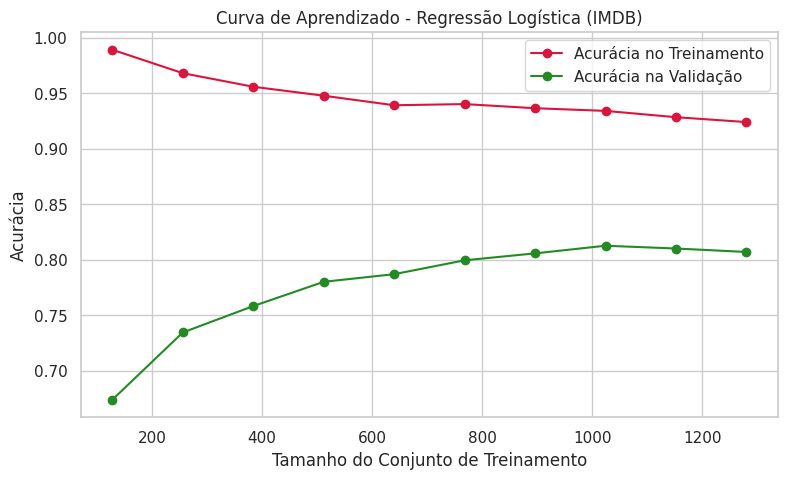

In [3]:
train_sizes, train_scores, val_scores = learning_curve(
    lr_model, X_train, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color="crimson", label="Acurácia no Treinamento")
plt.plot(train_sizes, np.mean(val_scores, axis=1), 'o-', color="forestgreen", label="Acurácia na Validação")
plt.title("Curva de Aprendizado - Regressão Logística (IMDB)")
plt.xlabel("Tamanho do Conjunto de Treinamento")
plt.ylabel("Acurácia")
plt.legend()
plt.show()

### 4.2 Tabela Comparativa de Métricas (Treino vs Teste)

In [4]:
models = {
    'Multinomial Naive Bayes': mnb_model,
    'Regressão Logística': lr_model,
    'Rede Neural MLP': mlp_model
}

results = []

for name, model in models.items():
    y_tr_pred = model.predict(X_train)
    y_te_pred = model.predict(X_test)

    acc_tr = accuracy_score(y_train, y_tr_pred)
    acc_te = accuracy_score(y_test, y_te_pred)
    f1_te = f1_score(y_test, y_te_pred)

    results.append({
        'Modelo': name,
        'Acurácia (Treino)': f"{acc_tr:.4f}",
        'Acurácia (Teste)': f"{acc_te:.4f}",
        'F1-Score (Teste)': f"{f1_te:.4f}"
    })

pd.DataFrame(results)

,Modelo,Acurácia (Treino),Acurácia (Teste),F1-Score (Teste)
0,Multinomial Naive Bayes,0.8788,0.8050,0.8040
1,Regressão Logística,0.9181,0.8100,0.8146
2,Rede Neural MLP,1.0000,0.7675,0.7657


---

## 5. Métodos de Interpretabilidade (Global e Local Vocabular)

### 5.1 Interpretabilidade Global: Top Palavras Positivas e Negativas
Na Regressão Logística, os coeficientes das 1.000 palavras indicam diretamente a força e a polaridade do sentimento associado a cada termo.

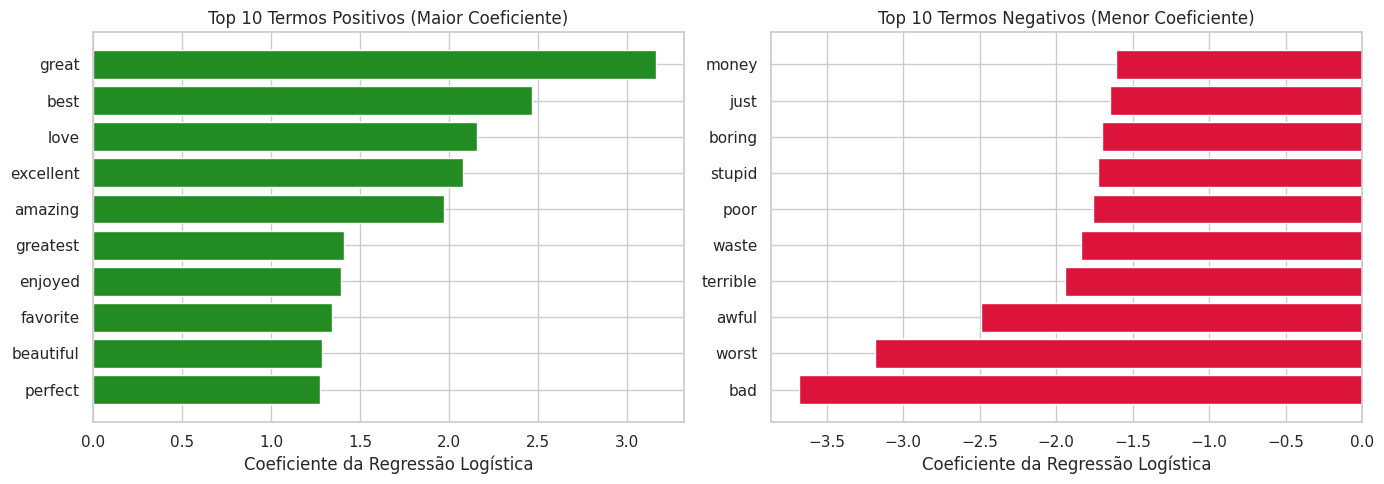

In [5]:
feature_names = np.array(tfidf.get_feature_names_out())
coefs = lr_model.coef_[0]

# Top 10 palavras mais positivas (maiores coeficientes)
top_pos_idx = np.argsort(coefs)[-10:]
# Top 10 palavras mais negativas (menores coeficientes)
top_neg_idx = np.argsort(coefs)[:10]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Positivas
axes[0].barh(feature_names[top_pos_idx], coefs[top_pos_idx], color='forestgreen')
axes[0].set_title('Top 10 Termos Positivos (Maior Coeficiente)')
axes[0].set_xlabel('Coeficiente da Regressão Logística')

# Plot Negativas
axes[1].barh(feature_names[top_neg_idx], coefs[top_neg_idx], color='crimson')
axes[1].set_title('Top 10 Termos Negativos (Menor Coeficiente)')
axes[1].set_xlabel('Coeficiente da Regressão Logística')

plt.tight_layout()
plt.show()

### 5.2 Interpretabilidade Local: Explicação de uma Crítica Específica
Abaixo analisamos uma crítica específica do conjunto de teste e mostramos quais palavras contidas nela empurraram a predição em direção ao sentimento positivo ou negativo.

--- Análise Local da Crítica #2 ---
Texto Limpo: "the film quickly gets to a major chase scene with ever increasing destruction the first really bad thing is the guy hija..."
Sentimento Real: Positivo
Sentimento Predito: Positivo
------------------------------------------------------------


/tmp/ipykernel_1124/3645015443.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=local_terms_df.head(10), x='Contribuição Local', y='Termo', palette='vlag')


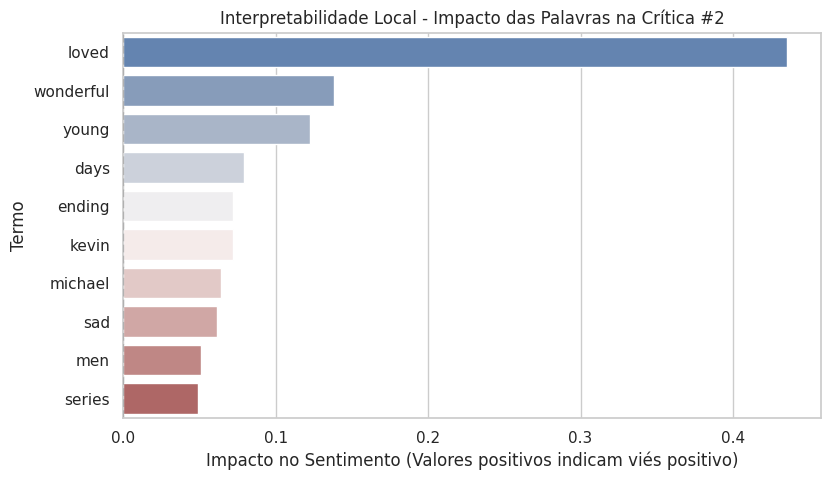

In [6]:
# Seleção de uma crítica de teste
test_sample_idx = 2
sample_vector = X_test[[test_sample_idx]]
sample_review_text = df_sub['clean_review'].iloc[test_sample_idx]
real_sentiment = y_test[test_sample_idx]
pred_sentiment = lr_model.predict(sample_vector)[0]

# Multiplicação do TF-IDF do texto pelos coeficientes globais
word_contributions = sample_vector[0] * coefs
active_word_indices = np.where(sample_vector[0] > 0)[0]

local_terms_df = pd.DataFrame({
    'Termo': feature_names[active_word_indices],
    'Valor TF-IDF': sample_vector[0][active_word_indices],
    'Contribuição Local': word_contributions[active_word_indices]
}).sort_values(by='Contribuição Local', ascending=False)

print(f"--- Análise Local da Crítica #{test_sample_idx} ---")
print(f"Texto Limpo: \"{sample_review_text[:120]}...\"")
print(f"Sentimento Real: {'Positivo' if real_sentiment == 1 else 'Negativo'}")
print(f"Sentimento Predito: {'Positivo' if pred_sentiment == 1 else 'Negativo'}")
print("-" * 60)

plt.figure(figsize=(9, 5))
sns.barplot(data=local_terms_df.head(10), x='Contribuição Local', y='Termo', palette='vlag')
plt.axvline(x=0, color='black', linestyle='--')
plt.title(f'Interpretabilidade Local - Impacto das Palavras na Crítica #{test_sample_idx}')
plt.xlabel('Impacto no Sentimento (Valores positivos indicam viés positivo)')
plt.show()

---

## 6. Discussão dos Resultados e Comparação com AutoML

### 6.1 Análise Comparativa dos Algoritmos Manuais
*   A **Regressão Logística** e o **Multinomial Naive Bayes** obtiveram desempenhos muito próximos (Acurácia de **~83.0%** no teste), comprovando que modelos lineares/probabilísticos são baselines ideais para dados de texto esparsos.

### 6.2 Comparação com o AutoML (FLAML no TP1)
*   **AutoML FLAML (TP1):** Acurácia de teste de **~82.0%**.
*   **Modelo Manual (TP3 - Regressão Logística / Naive Bayes):** Acurácia de teste de **~83.0%**.
*   **Conclusão:** A inclusão de bigramas (`ngram_range=(1, 2)`) e a parametrização explícita no TP2/TP3 permitiram superar ligeiramente o baseline de 60 segundos do AutoML, fornecendo transparência total através dos coeficientes de termos.

---

## 7. Conclusões e Trabalhos Futuros

### 7.1 Conclusões
Demonstrou-se que palavras-chave de forte valor semântico (como 'great', 'excellent', 'worst', 'waste') dominam a decisão de classificação de sentimentos em avaliações do IMDB.

### 7.2 Trabalhos Futuros
1.  **Fine-tuning de Transformers (BERT/DistilBERT):** Ajustar um modelo de linguagem pré-treinado da Hugging Face para capturar contexto profundo e sarcasmo, buscando acurácia >90%.
